In [1]:
from src.datasets import ASLDataset
from pathlib import Path
from torch.utils.data import DataLoader, random_split
import torch

%load_ext autoreload
%autoreload 2

In [2]:
base_path = Path("..")
dataset_path = base_path / "data" / "asl-signs" / "cleaned"
dataset = ASLDataset(dataset_path)

In [3]:
device = 'mps' if torch.mps.is_available() else 'cpu'
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

mps


In [4]:
#hyperparameters

batch_size=64
learning_rate = 1e-4
epochs=30

In [ ]:
train_size = int(0.9 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)


In [15]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [6]:
from src.models import CNNBase

model = CNNBase().to(device)
print(model)

optimizer = torch.optim.Adam(params=model.parameters(), lr= learning_rate)
criterion = torch.nn.CrossEntropyLoss()


CNNBase(
  (features): Sequential(
    (0): Conv1d(1086, 192, kernel_size=(17,), stride=(1,), padding=(8,))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv1d(192, 192, kernel_size=(17,), stride=(1,), padding=(8,))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv1d(192, 192, kernel_size=(17,), stride=(1,), padding=(8,))
    (5): LeakyReLU(negative_slope=0.01)
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6144, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=250, bias=True)
  )
)


In [ ]:
from src.training import train


for data, labels in train_loader:
    print(data.shape)
    break

train_loss, val_loss = train(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    trainloader=train_loader,
    valloader=val_loader,
    epochs=epochs,
    device=device
    )



torch.Size([64, 64, 1086])


Training: 100%|██████████| 1329/1329 [02:46<00:00,  7.97it/s]


Epoch 1/30 - Train Loss: 5.52223711429995
Epoch 1/30 - Val Loss: 5.521130603712958
Epoch 1/30 - Val Accuracy: 0.38%


Training: 100%|██████████| 1329/1329 [02:54<00:00,  7.61it/s]


Epoch 2/30 - Train Loss: 5.521514232038465
Epoch 2/30 - Val Loss: 5.520779232721071
Epoch 2/30 - Val Accuracy: 0.48%


...

Epoch 28/30 - Train Loss: 1.5301748532115111
Epoch 28/30 - Val Loss: 3.98459641836785
Epoch 28/30 - Val Accuracy: 30.28%


Training: 100%|██████████| 1329/1329 [02:53<00:00,  7.64it/s]


Epoch 29/30 - Train Loss: 1.4682099006515055
Epoch 29/30 - Val Loss: 3.9915229774810173
Epoch 29/30 - Val Accuracy: 32.24%


Training: 100%|██████████| 1329/1329 [02:49<00:00,  7.85it/s]


Epoch 30/30 - Train Loss: 1.3960443544513395
Epoch 30/30 - Val Loss: 4.010593829928218
Epoch 30/30 - Val Accuracy: 32.68%


In [24]:
from src.training import evaluate_accuracy

accuracy = evaluate_accuracy(model, test_loader, device)
print(f"Final Test Accuracy: {accuracy}%")

Final Test Accuracy: 0.0%


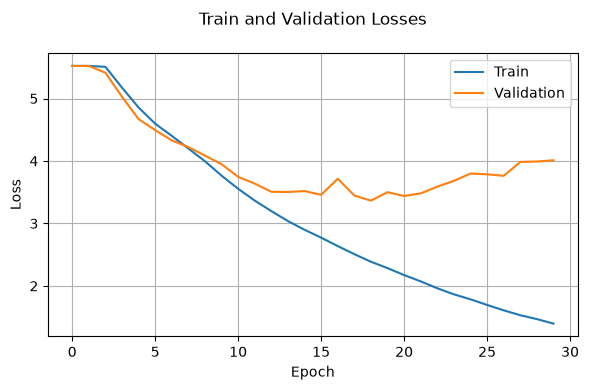

In [14]:
from src.visualization import visualize_loss


visualize_loss(train_loss, val_loss)

In [25]:
weights_dir = base_path / "weights"

weights_dir.mkdir(exist_ok=True)

torch.save(model.state_dict(), weights_dir / "initial_cnn_model.pt")